In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Celda 1 — Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import (
    PoseLandmarksConnections,
    drawing_utils,
    drawing_styles,
)
from enum import IntEnum
from pathlib import Path
import time

print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version: {cv2.__version__}")

MediaPipe version: 0.10.35
OpenCV version: 4.13.0


In [5]:
#Celda 2 — Constantes y utilidades reutilizables

class PoseLandmark(IntEnum):
    """Índices de los 33 landmarks de MediaPipe Pose."""
    NOSE = 0
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_KNEE = 25
    RIGHT_KNEE = 26
    LEFT_ANKLE = 27
    RIGHT_ANKLE = 28


VIDEO_PATH = Path("/home/fabian/AIronVision/ml/data/Sentadilla_Test.mp4")
MODEL_PATH = Path("/home/fabian/AIronVision/ml/models/pose_landmarker_heavy.task")
OUTPUT_DIR = Path("/home/fabian/AIronVision/ml/output")
OUTPUT_DIR.mkdir(exist_ok=True)


def calculate_angle_2d(point_a, point_b, point_c) -> float:
    """Calcula el ángulo en B formado por A-B-C en grados (0-180)."""
    a = np.array([point_a.x, point_a.y]) if hasattr(point_a, 'x') else np.array(point_a)
    b = np.array([point_b.x, point_b.y]) if hasattr(point_b, 'x') else np.array(point_b)
    c = np.array([point_c.x, point_c.y]) if hasattr(point_c, 'x') else np.array(point_c)

    ba = a - b
    bc = c - b

    mag_ba = np.linalg.norm(ba)
    mag_bc = np.linalg.norm(bc)
    if mag_ba == 0 or mag_bc == 0:
        return 0.0

    cosine = np.clip(np.dot(ba, bc) / (mag_ba * mag_bc), -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))



In [6]:
# Celda 3 — Diagnóstico del video (CRÍTICO antes de procesar)

def inspect_video(video_path: Path) -> dict:
    """Extrae metadata del video sin procesar nada."""
    if not video_path.exists():
        raise FileNotFoundError(f"No se encontró el video: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"OpenCV no pudo abrir el video: {video_path}")

    info = {
        "path": str(video_path),
        "size_mb": video_path.stat().st_size / (1024 * 1024),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fourcc": int(cap.get(cv2.CAP_PROP_FOURCC)),
    }
    info["duration_sec"] = info["frame_count"] / info["fps"] if info["fps"] > 0 else 0
    info["aspect_ratio"] = info["width"] / info["height"] if info["height"] > 0 else 0

    # Decodificar el código FOURCC a string legible
    fourcc_bytes = info["fourcc"].to_bytes(4, byteorder='little')
    info["codec"] = fourcc_bytes.decode('ascii', errors='ignore')

    cap.release()
    return info


video_info = inspect_video(VIDEO_PATH)

print("📹 Información del video:\n")
for key, value in video_info.items():
    if isinstance(value, float):
        print(f"  {key:<15}: {value:.2f}")
    else:
        print(f"  {key:<15}: {value}")

📹 Información del video:

  path           : /home/fabian/AIronVision/ml/data/Sentadilla_Test.mp4
  size_mb        : 47.70
  fps            : 30.00
  frame_count    : 711
  width          : 1080
  height         : 1920
  fourcc         : 875967080
  duration_sec   : 23.70
  aspect_ratio   : 0.56
  codec          : h264


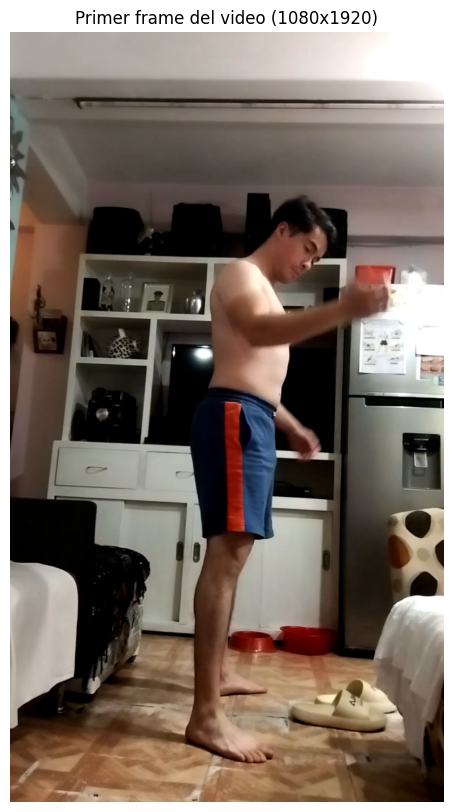

In [7]:
# Celda 4 — Ver el primer frame (verificación visual)

cap = cv2.VideoCapture(str(VIDEO_PATH))
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    print("❌ No se pudo leer el primer frame")
else:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 10))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.title(f"Primer frame del video ({frame_rgb.shape[1]}x{frame_rgb.shape[0]})")
    plt.show()

In [8]:
# Celda 5 — Configurar detector en modo VIDEO

def create_video_detector(model_path: Path):
    """Crea un PoseLandmarker configurado para procesar video."""
    base_options = mp_python.BaseOptions(model_asset_path=str(model_path))
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,  # Modo VIDEO, no IMAGE
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return vision.PoseLandmarker.create_from_options(options)


detector = create_video_detector(MODEL_PATH)
print("✅ Detector de video creado")

✅ Detector de video creado


I0000 00:00:1777587053.042344   14736 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777587053.058931   14772 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.6), renderer: AMD Radeon 890M Graphics (radeonsi, gfx1150, LLVM 21.1.8, DRM 3.64, 6.19.14-200.fc43.x86_64)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777587053.089481   14749 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777587053.119570   14760 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [9]:
# Celda 6 — Funciones auxiliares para análisis

def get_best_side(landmarks) -> str:
    """Devuelve 'left' o 'right' según qué lado tiene mejor visibility."""
    left_vis = np.mean([
        landmarks[PoseLandmark.LEFT_HIP].visibility,
        landmarks[PoseLandmark.LEFT_KNEE].visibility,
        landmarks[PoseLandmark.LEFT_ANKLE].visibility,
    ])
    right_vis = np.mean([
        landmarks[PoseLandmark.RIGHT_HIP].visibility,
        landmarks[PoseLandmark.RIGHT_KNEE].visibility,
        landmarks[PoseLandmark.RIGHT_ANKLE].visibility,
    ])
    return ("right", right_vis) if right_vis > left_vis else ("left", left_vis)


def extract_frame_features(landmarks) -> dict:
    """
    Extrae todas las métricas relevantes de una pose detectada en un frame.
    Esta función es el corazón del análisis: lo que aquí calculemos
    es lo que después alimenta detección de errores y métricas.
    """
    side, side_visibility = get_best_side(landmarks)

    if side == "right":
        hip = landmarks[PoseLandmark.RIGHT_HIP]
        knee = landmarks[PoseLandmark.RIGHT_KNEE]
        ankle = landmarks[PoseLandmark.RIGHT_ANKLE]
        shoulder = landmarks[PoseLandmark.RIGHT_SHOULDER]
    else:
        hip = landmarks[PoseLandmark.LEFT_HIP]
        knee = landmarks[PoseLandmark.LEFT_KNEE]
        ankle = landmarks[PoseLandmark.LEFT_ANKLE]
        shoulder = landmarks[PoseLandmark.LEFT_SHOULDER]

    knee_angle = calculate_angle_2d(hip, knee, ankle)
    # Inclinación del torso: ángulo cadera-hombro respecto a la vertical
    # (la calculamos como ángulo del segmento hombro-cadera con el eje Y)
    torso_angle = calculate_angle_2d(
        shoulder,
        hip,
        type('P', (), {'x': hip.x, 'y': hip.y + 0.1})(),  # Punto vertical debajo de cadera
    )

    return {
        "side": side,
        "side_visibility": side_visibility,
        "knee_angle": knee_angle,
        "torso_angle": torso_angle,
        "hip_y": hip.y,           # Útil para detectar fase del movimiento
        "knee_y": knee.y,
        "shoulder_y": shoulder.y,
        "hip_visibility": hip.visibility,
        "knee_visibility": knee.visibility,
        "ankle_visibility": ankle.visibility,
    }

In [10]:
# Celda 7 — Procesar el video completo

def process_video(video_path: Path, detector) -> pd.DataFrame:
    """
    Procesa un video frame por frame con MediaPipe y devuelve
    un DataFrame con las métricas extraídas de cada frame.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    rows = []
    frame_idx = 0
    start_time = time.time()

    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break

        # Convertir BGR → RGB y crear mp.Image
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

        # Timestamp en milisegundos basado en el FPS real
        timestamp_ms = int((frame_idx / fps) * 1000)

        # Detectar pose
        result = detector.detect_for_video(mp_image, timestamp_ms)

        # Extraer features
        row = {
            "frame": frame_idx,
            "timestamp_sec": frame_idx / fps,
            "pose_detected": False,
        }

        if result.pose_landmarks:
            features = extract_frame_features(result.pose_landmarks[0])
            row["pose_detected"] = True
            row.update(features)

        rows.append(row)
        frame_idx += 1

        # Progreso cada 50 frames
        if frame_idx % 50 == 0:
            elapsed = time.time() - start_time
            pct = (frame_idx / total_frames) * 100
            eta = (elapsed / frame_idx) * (total_frames - frame_idx)
            print(f"  Frame {frame_idx}/{total_frames} ({pct:.1f}%) - "
                  f"transcurrido: {elapsed:.1f}s - ETA: {eta:.1f}s")

    cap.release()
    elapsed = time.time() - start_time
    print(f"\n✅ Procesamiento completo: {frame_idx} frames en {elapsed:.1f}s "
          f"({frame_idx/elapsed:.1f} fps de procesamiento)")

    return pd.DataFrame(rows)


# Ejecutar (esto va a tardar unos minutos)
print("🎬 Procesando video...\n")
df = process_video(VIDEO_PATH, detector)
print(f"\n📊 DataFrame creado con {len(df)} filas y {len(df.columns)} columnas")
df.head()

W0000 00:00:1777587053.218676   14744 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


🎬 Procesando video...

  Frame 50/711 (7.0%) - transcurrido: 2.1s - ETA: 27.3s
  Frame 100/711 (14.1%) - transcurrido: 4.1s - ETA: 25.3s
  Frame 150/711 (21.1%) - transcurrido: 6.2s - ETA: 23.4s
  Frame 200/711 (28.1%) - transcurrido: 8.3s - ETA: 21.2s
  Frame 250/711 (35.2%) - transcurrido: 10.4s - ETA: 19.1s
  Frame 300/711 (42.2%) - transcurrido: 12.5s - ETA: 17.1s
  Frame 350/711 (49.2%) - transcurrido: 14.7s - ETA: 15.2s
  Frame 400/711 (56.3%) - transcurrido: 16.8s - ETA: 13.1s
  Frame 450/711 (63.3%) - transcurrido: 19.1s - ETA: 11.1s
  Frame 500/711 (70.3%) - transcurrido: 21.3s - ETA: 9.0s
  Frame 550/711 (77.4%) - transcurrido: 23.5s - ETA: 6.9s
  Frame 600/711 (84.4%) - transcurrido: 25.7s - ETA: 4.8s
  Frame 650/711 (91.4%) - transcurrido: 27.8s - ETA: 2.6s
  Frame 700/711 (98.5%) - transcurrido: 29.9s - ETA: 0.5s

✅ Procesamiento completo: 711 frames en 30.4s (23.4 fps de procesamiento)

📊 DataFrame creado con 711 filas y 13 columnas


,frame,timestamp_sec,pose_detected,side,side_visibility,knee_angle,torso_angle,hip_y,knee_y,shoulder_y,hip_visibility,knee_visibility,ankle_visibility
0,0,0.000000,True,right,0.982871,169.103204,165.791307,0.516519,0.685884,0.318006,0.999977,0.984533,0.964102
1,1,0.033333,True,right,0.960811,170.230277,167.667979,0.514137,0.686992,0.317788,0.999971,0.957219,0.925243
2,2,0.066667,True,right,0.934173,169.389948,168.629463,0.513113,0.686381,0.317678,0.999965,0.922705,0.879849
3,3,0.100000,True,right,0.928167,168.013509,169.105889,0.512711,0.686119,0.317357,0.999964,0.914572,0.869963
4,4,0.133333,True,right,0.925394,168.165501,169.371614,0.512716,0.686116,0.317366,0.999963,0.911307,0.864911


In [11]:
# Celda 8 — Estadísticas globales

print("📊 Estadísticas del DataFrame:\n")
print(df.describe())
print("\n")
print("🎯 Cobertura de detección:")
print(f"  Frames con pose detectada: {df['pose_detected'].sum()}/{len(df)} ({df['pose_detected'].mean()*100:.1f}%)")
print(f"  Lado elegido predominante: {df['side'].mode().values[0] if 'side' in df.columns else 'N/A'}")
print(f"  Distribución de lados: {df['side'].value_counts().to_dict() if 'side' in df.columns else 'N/A'}")

📊 Estadísticas del DataFrame:

            frame  timestamp_sec  side_visibility  knee_angle  torso_angle  \
count  711.000000     711.000000       711.000000  711.000000   711.000000   
mean   355.000000      11.833333         0.963145  107.545097   132.355759   
std    205.392308       6.846410         0.049910   40.993421    16.091720   
min      0.000000       0.000000         0.723138   55.193620   111.582452   
25%    177.500000       5.916667         0.956477   67.903790   116.773848   
50%    355.000000      11.833333         0.982245   97.328461   128.673907   
75%    532.500000      17.750000         0.989295  152.371213   147.270230   
max    710.000000      23.666667         0.996852  170.230277   179.473468   

            hip_y      knee_y  shoulder_y  hip_visibility  knee_visibility  \
count  711.000000  711.000000  711.000000      711.000000       711.000000   
mean     0.581889    0.706858    0.420694        0.999965         0.940689   
std      0.068549    0.018123   

In [12]:
# Celda 9 — Verificar consistencia del lado elegido

# Si el sujeto se mantiene de perfil, esperamos que el lado elegido sea estable
side_counts = df[df['pose_detected']]['side'].value_counts()
print("Distribución de lado elegido por frame:")
print(side_counts)

# ¿Hay frames donde cambió?
side_changes = (df['side'] != df['side'].shift()).sum() - 1  # -1 porque la primera siempre cuenta
print(f"\nCambios de lado durante el video: {side_changes}")
print("(Si hay muchos cambios, hay que añadir suavizado temporal del lado elegido)")

Distribución de lado elegido por frame:
side
right    711
Name: count, dtype: int64

Cambios de lado durante el video: 0
(Si hay muchos cambios, hay que añadir suavizado temporal del lado elegido)


/tmp/ipykernel_10800/3919550197.py:26: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fabian/anaconda3/envs/aironvision-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


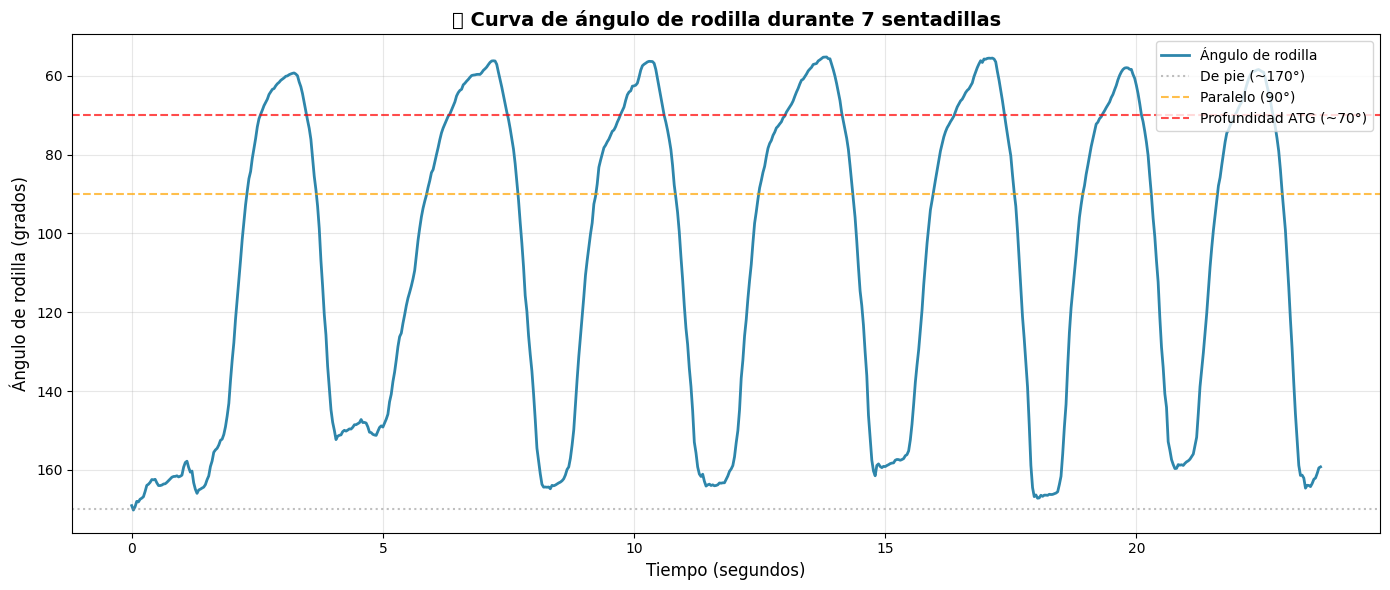

In [13]:
# Celda 10 — La firma de la sentadilla

import matplotlib.pyplot as plt

# Solo frames con detección (en este caso son todos)
df_valid = df[df['pose_detected']].copy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_valid['timestamp_sec'], df_valid['knee_angle'],
        color='#2E86AB', linewidth=2, label='Ángulo de rodilla')

# Líneas de referencia biomecánicas
ax.axhline(y=170, color='gray', linestyle=':', alpha=0.5, label='De pie (~170°)')
ax.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='Paralelo (90°)')
ax.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Profundidad ATG (~70°)')

ax.set_xlabel('Tiempo (segundos)', fontsize=12)
ax.set_ylabel('Ángulo de rodilla (grados)', fontsize=12)
ax.set_title('🏋️ Curva de ángulo de rodilla durante 7 sentadillas',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # Invertir Y para que "abajo" en la curva = "abajo" en la sentadilla

plt.tight_layout()
plt.show()

In [14]:
pip install scipy 


Note: you may need to restart the kernel to use updated packages.


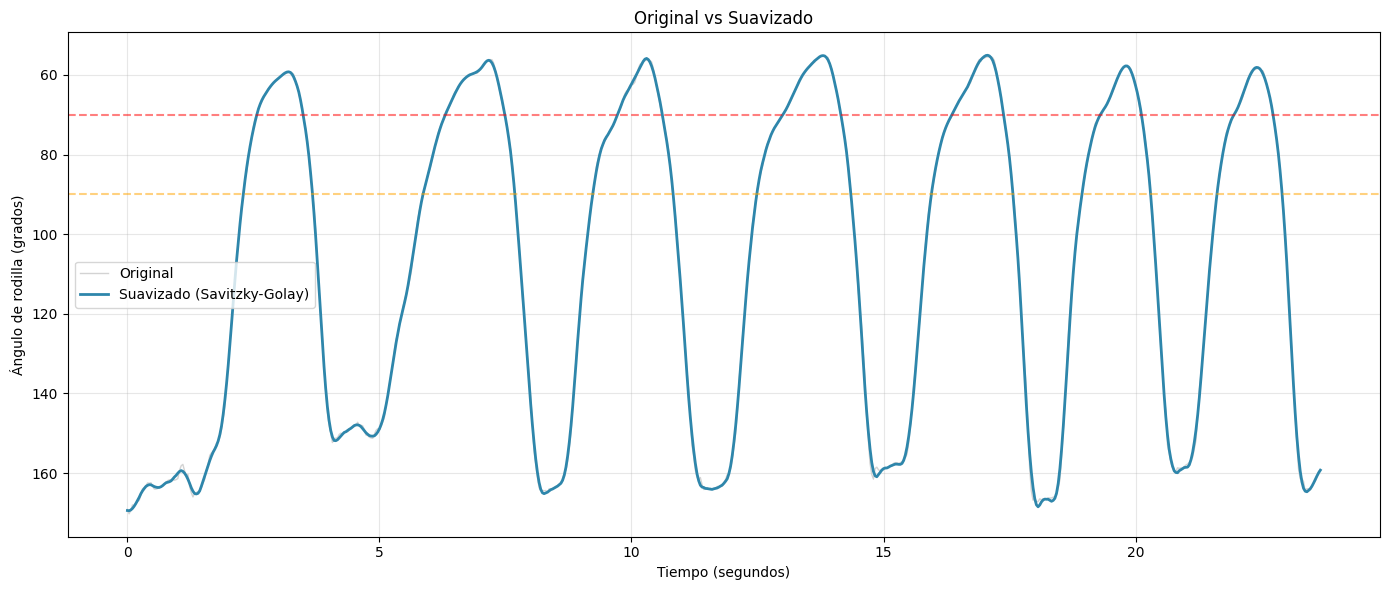

In [15]:
#Celda 11 — Suavizado de la señal
from scipy.signal import savgol_filter

# Filtro Savitzky-Golay: suaviza preservando picos y valles (ideal para esto)
# window_length=15 (medio segundo a 30fps), polyorder=3
df_valid['knee_angle_smooth'] = savgol_filter(
    df_valid['knee_angle'].values,
    window_length=15,
    polyorder=3,
)

# Comparación visual: original vs suavizado
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_valid['timestamp_sec'], df_valid['knee_angle'],
        color='lightgray', linewidth=1, label='Original')
ax.plot(df_valid['timestamp_sec'], df_valid['knee_angle_smooth'],
        color='#2E86AB', linewidth=2, label='Suavizado (Savitzky-Golay)')

ax.axhline(y=90, color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('Ángulo de rodilla (grados)')
ax.set_title('Original vs Suavizado')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Celda 12 — Detección automática de repeticiones

from scipy.signal import find_peaks

# find_peaks busca máximos. Para encontrar mínimos, invertimos la señal.
inverted_signal = -df_valid['knee_angle_smooth'].values

# Parámetros importantes:
# - height: el mínimo debe ser MENOR que -100° (es decir, ángulo < 100°)
#   Esto excluye cualquier mini-bajada que no llegue ni a paralelo
# - distance: separación mínima de 30 frames (~1 segundo) entre reps
peaks_idx, properties = find_peaks(
    inverted_signal,
    height=-100,    # equivalente a "ángulo mínimo < 100°"
    distance=30,    # separación mínima en frames
    prominence=20,  # debe ser un valle "bien marcado"
)

# Convertir índices del array a información del DataFrame
reps = df_valid.iloc[peaks_idx].copy()

print(f"🏋️ Repeticiones detectadas: {len(reps)}\n")
print("Detalle por repetición:")
print(f"{'#':>3} {'Tiempo (s)':>12} {'Ángulo mín (°)':>16} {'Profundidad':>15}")
print("-" * 55)

for i, (idx, row) in enumerate(reps.iterrows(), 1):
    angle = row['knee_angle_smooth']
    if angle < 70:
        depth_label = "ATG ✓"
    elif angle < 90:
        depth_label = "Paralelo ✓"
    elif angle < 110:
        depth_label = "Cerca paralelo"
    else:
        depth_label = "Parcial ⚠️"
    print(f"{i:>3} {row['timestamp_sec']:>12.2f} {angle:>16.1f} {depth_label:>15}")

🏋️ Repeticiones detectadas: 7

Detalle por repetición:
  #   Tiempo (s)   Ángulo mín (°)     Profundidad
-------------------------------------------------------
  1         3.20             59.2           ATG ✓
  2         7.17             56.3           ATG ✓
  3        10.30             55.9           ATG ✓
  4        13.80             55.2           ATG ✓
  5        17.07             55.1           ATG ✓
  6        19.80             57.8           ATG ✓
  7        22.40             58.1           ATG ✓


/tmp/ipykernel_10800/1209984359.py:26: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/fabian/anaconda3/envs/aironvision-ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


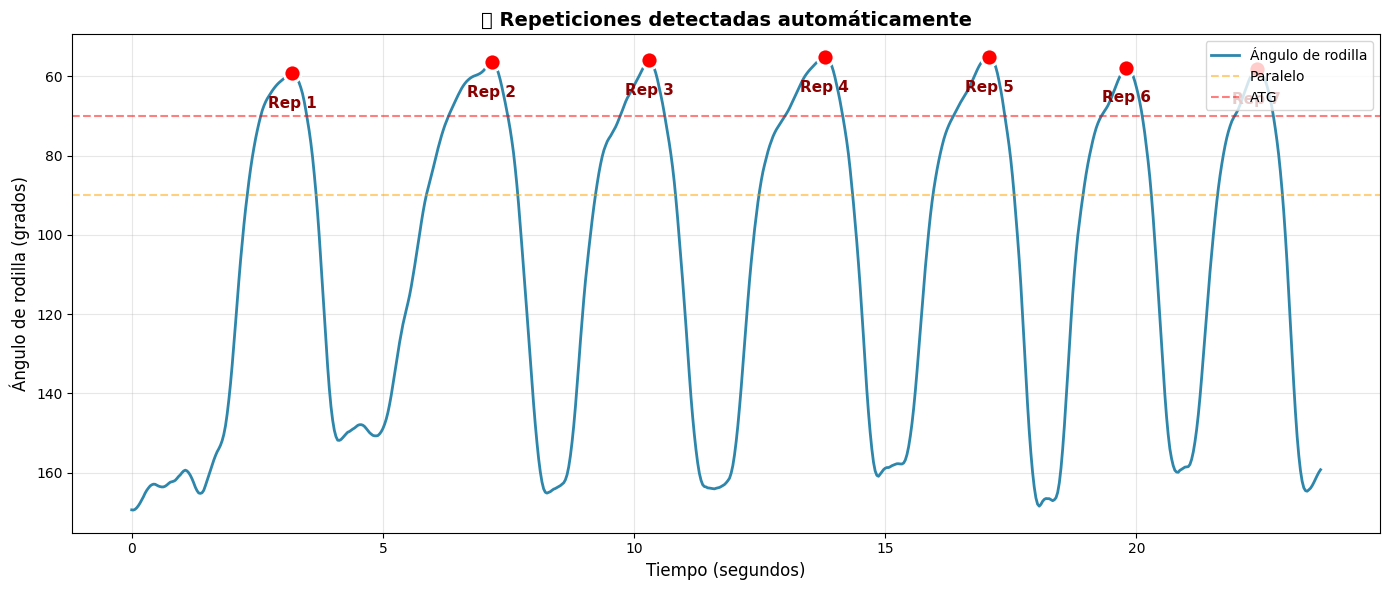

In [17]:
# Celda 13 — Visualización con reps marcadas

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_valid['timestamp_sec'], df_valid['knee_angle_smooth'],
        color='#2E86AB', linewidth=2, label='Ángulo de rodilla')

# Marcar cada rep con un punto y número
for i, (idx, row) in enumerate(reps.iterrows(), 1):
    ax.scatter(row['timestamp_sec'], row['knee_angle_smooth'],
               color='red', s=150, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(f'Rep {i}',
                xy=(row['timestamp_sec'], row['knee_angle_smooth']),
                xytext=(0, -25), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold',
                color='darkred')

ax.axhline(y=90, color='orange', linestyle='--', alpha=0.5, label='Paralelo')
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='ATG')
ax.set_xlabel('Tiempo (segundos)', fontsize=12)
ax.set_ylabel('Ángulo de rodilla (grados)', fontsize=12)
ax.set_title('🎯 Repeticiones detectadas automáticamente', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# Celda 14 — Resumen de la serie

# Calcular intervalos entre reps (cadencia)
rep_times = reps['timestamp_sec'].values
intervals = np.diff(rep_times)

# Estadísticas de la serie completa
session_summary = {
    "total_reps": len(reps),
    "duration_sec": rep_times[-1] - rep_times[0],
    "min_depth_angle": float(reps['knee_angle_smooth'].min()),
    "max_depth_angle": float(reps['knee_angle_smooth'].max()),
    "mean_depth_angle": float(reps['knee_angle_smooth'].mean()),
    "depth_consistency_std": float(reps['knee_angle_smooth'].std()),
    "deepest_rep_number": int(reps['knee_angle_smooth'].idxmin()),
    "shallowest_rep_number": int(reps['knee_angle_smooth'].idxmax()),
    "avg_interval_between_reps": float(intervals.mean()),
    "tempo_trend": "accelerating" if intervals[-2:].mean() < intervals[:2].mean() else "stable_or_decelerating",
}

print("📊 RESUMEN DE LA SERIE\n")
print(f"  Total de reps:           {session_summary['total_reps']}")
print(f"  Duración:                {session_summary['duration_sec']:.1f}s")
print(f"  Profundidad mínima:      {session_summary['min_depth_angle']:.1f}° (más profunda)")
print(f"  Profundidad máxima:      {session_summary['max_depth_angle']:.1f}° (menos profunda)")
print(f"  Profundidad promedio:    {session_summary['mean_depth_angle']:.1f}°")
print(f"  Consistencia (std):      {session_summary['depth_consistency_std']:.2f}°")
print(f"  Cadencia promedio:       {session_summary['avg_interval_between_reps']:.2f}s entre reps")
print(f"  Tendencia de tempo:      {session_summary['tempo_trend']}")

📊 RESUMEN DE LA SERIE

  Total de reps:           7
  Duración:                19.2s
  Profundidad mínima:      55.1° (más profunda)
  Profundidad máxima:      59.2° (menos profunda)
  Profundidad promedio:    56.8°
  Consistencia (std):      1.60°
  Cadencia promedio:       3.20s entre reps
  Tendencia de tempo:      accelerating


In [19]:
# Celda 15 — Pre-cálculos para anotación

# Asignar a cada frame su número de rep en curso
df_valid = df_valid.reset_index(drop=True)
df_valid['rep_count'] = 0  # Reps completadas hasta este frame
df_valid['current_rep'] = 0  # Rep en curso (1-7) o 0 si está descansando

# Los timestamps de los valles (puntos más profundos de cada rep)
rep_timestamps = reps['timestamp_sec'].values

for i, t in enumerate(rep_timestamps, start=1):
    # Después del valle de la rep i, la rep i ya cuenta como completa
    df_valid.loc[df_valid['timestamp_sec'] > t, 'rep_count'] = i

# Determinar la rep en curso: estamos en la rep i si:
# - aún no completamos la rep i (rep_count < i)
# - hemos pasado el inicio (heurística: el ángulo bajó significativamente)
# Para simplificar: la rep en curso es siempre rep_count + 1 mientras haya reps por hacer
df_valid['current_rep'] = df_valid['rep_count'] + 1
df_valid.loc[df_valid['rep_count'] >= len(reps), 'current_rep'] = len(reps)

print(df_valid[['frame', 'timestamp_sec', 'knee_angle_smooth', 'rep_count', 'current_rep']].head(20))

    frame  timestamp_sec  knee_angle_smooth  rep_count  current_rep
0       0       0.000000         169.402576          0            1
1       1       0.033333         169.457576          0            1
2       2       0.066667         169.272630          0            1
3       3       0.100000         168.886259          0            1
4       4       0.133333         168.336981          0            1
5       5       0.166667         167.663316          0            1
6       6       0.200000         166.903785          0            1
7       7       0.233333         166.096906          0            1
8       8       0.266667         165.186506          0            1
9       9       0.300000         164.462107          0            1
10     10       0.333333         163.879499          0            1
11     11       0.366667         163.365637          0            1
12     12       0.400000         163.077517          0            1
13     13       0.433333         162.918848     

In [20]:
# Celda 16 — Función de anotación de un frame

def annotate_frame(frame_bgr, frame_data, detection_result, video_height, video_width):
    """
    Anota un frame con esqueleto, ángulo, contador de reps y métricas.
    
    Args:
        frame_bgr: Frame original en BGR (OpenCV nativo).
        frame_data: Fila del DataFrame con métricas de este frame.
        detection_result: Resultado de MediaPipe para este frame.
        video_height, video_width: Dimensiones del video.
    
    Returns:
        Frame anotado en BGR.
    """
    annotated = frame_bgr.copy()
    
    # 1. Dibujar esqueleto si hay detección
    if detection_result and detection_result.pose_landmarks:
        landmark_style = drawing_styles.get_default_pose_landmarks_style()
        connection_style = drawing_utils.DrawingSpec(
            color=(0, 255, 100),  # verde lima
            thickness=3,
        )
        for pose_landmarks in detection_result.pose_landmarks:
            drawing_utils.draw_landmarks(
                image=annotated,
                landmark_list=pose_landmarks,
                connections=PoseLandmarksConnections.POSE_LANDMARKS,
                landmark_drawing_spec=landmark_style,
                connection_drawing_spec=connection_style,
            )
    
    # 2. Panel superior: contador de reps y ángulo actual
    # Fondo semi-transparente
    overlay = annotated.copy()
    cv2.rectangle(overlay, (0, 0), (video_width, 180), (0, 0, 0), -1)
    annotated = cv2.addWeighted(overlay, 0.55, annotated, 0.45, 0)
    
    # Contador de reps (grande, izquierda)
    rep_text = f"REP {int(frame_data['current_rep'])}/{int(reps_total)}"
    cv2.putText(annotated, rep_text, (40, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 2.5, (255, 255, 255), 5)
    cv2.putText(annotated, rep_text, (40, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 2.5, (0, 255, 200), 3)
    
    # Subtexto: completadas
    completed_text = f"Completadas: {int(frame_data['rep_count'])}"
    cv2.putText(annotated, completed_text, (40, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (200, 200, 200), 2)
    
    # Ángulo actual (derecha del panel superior)
    if frame_data.get('pose_detected', False):
        angle = frame_data['knee_angle_smooth']
        # Color del ángulo según profundidad
        if angle < 70:
            angle_color = (0, 255, 100)   # Verde - excelente
            depth_label = "ATG"
        elif angle < 90:
            angle_color = (0, 220, 255)   # Amarillo - paralelo
            depth_label = "PARALELO"
        elif angle < 120:
            angle_color = (0, 165, 255)   # Naranja - parcial
            depth_label = "PARCIAL"
        else:
            angle_color = (200, 200, 200) # Gris - de pie
            depth_label = "DE PIE"
        
        angle_text = f"{angle:.0f}"
        cv2.putText(annotated, angle_text, (video_width - 280, 110),
                    cv2.FONT_HERSHEY_SIMPLEX, 3.0, (255, 255, 255), 7)
        cv2.putText(annotated, angle_text, (video_width - 280, 110),
                    cv2.FONT_HERSHEY_SIMPLEX, 3.0, angle_color, 4)
        
        # Símbolo de grado y label
        cv2.putText(annotated, "deg", (video_width - 130, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
        cv2.putText(annotated, depth_label, (video_width - 280, 160),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, angle_color, 2)
    
    # 3. Watermark inferior derecho
    cv2.putText(annotated, "AIronVision", (video_width - 320, video_height - 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 200), 2)
    
    return annotated


reps_total = len(reps)
print(f"Función de anotación lista. Total reps a marcar: {reps_total}")

Función de anotación lista. Total reps a marcar: 7


In [21]:
# Celda 17 — Generar el video anotado

def generate_annotated_video(
    input_path: Path,
    output_path: Path,
    df_features: pd.DataFrame,
    detector,
):
    """
    Genera un video anotado con esqueleto, ángulos, y contador de reps.
    """
    cap = cv2.VideoCapture(str(input_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Codec para mp4 (H.264 si está disponible, mp4v como fallback universal)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    if not writer.isOpened():
        raise RuntimeError(f"No se pudo abrir el writer para {output_path}")
    
    frame_idx = 0
    start_time = time.time()
    
    while True:
        ret, frame_bgr = cap.read()
        if not ret:
            break
        
        # Detectar pose otra vez (necesitamos el result completo para dibujar)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int((frame_idx / fps) * 1000)
        result = detector.detect_for_video(mp_image, timestamp_ms)
        
        # Obtener datos del DataFrame para este frame
        if frame_idx < len(df_features):
            frame_data = df_features.iloc[frame_idx]
        else:
            frame_data = {'pose_detected': False, 'current_rep': 0, 'rep_count': 0}
        
        # Anotar y escribir
        annotated = annotate_frame(frame_bgr, frame_data, result, height, width)
        writer.write(annotated)
        
        frame_idx += 1
        if frame_idx % 50 == 0:
            elapsed = time.time() - start_time
            pct = (frame_idx / total_frames) * 100
            eta = (elapsed / frame_idx) * (total_frames - frame_idx)
            print(f"  Frame {frame_idx}/{total_frames} ({pct:.1f}%) - ETA: {eta:.1f}s")
    
    cap.release()
    writer.release()
    elapsed = time.time() - start_time
    print(f"\n✅ Video generado: {output_path}")
    print(f"   Tiempo total: {elapsed:.1f}s ({frame_idx/elapsed:.1f} fps)")


# IMPORTANTE: necesitamos un detector NUEVO porque el anterior ya consumió el video
# (en modo VIDEO, el detector mantiene timestamps internos crecientes)
detector_v2 = create_video_detector(MODEL_PATH)

OUTPUT_VIDEO = OUTPUT_DIR / "Sentadilla_Test_annotated.mp4"

print("🎬 Generando video anotado...\n")
generate_annotated_video(VIDEO_PATH, OUTPUT_VIDEO, df_valid, detector_v2)

print(f"\n📁 Video guardado en: {OUTPUT_VIDEO.absolute()}")
print(f"   Tamaño: {OUTPUT_VIDEO.stat().st_size / (1024*1024):.1f} MB")

I0000 00:00:1777587160.287963   14894 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1777587160.291399   14924 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.3.6), renderer: AMD Radeon 890M Graphics (radeonsi, gfx1150, LLVM 21.1.8, DRM 3.64, 6.19.14-200.fc43.x86_64)
W0000 00:00:1777587160.319266   14910 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777587160.350724   14913 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


🎬 Generando video anotado...

  Frame 50/711 (7.0%) - ETA: 35.2s
  Frame 100/711 (14.1%) - ETA: 32.5s
  Frame 150/711 (21.1%) - ETA: 29.7s
  Frame 200/711 (28.1%) - ETA: 26.7s
  Frame 250/711 (35.2%) - ETA: 24.1s
  Frame 300/711 (42.2%) - ETA: 21.5s
  Frame 350/711 (49.2%) - ETA: 19.0s
  Frame 400/711 (56.3%) - ETA: 16.3s
  Frame 450/711 (63.3%) - ETA: 13.6s
  Frame 500/711 (70.3%) - ETA: 11.0s
  Frame 550/711 (77.4%) - ETA: 8.4s
  Frame 600/711 (84.4%) - ETA: 5.8s
  Frame 650/711 (91.4%) - ETA: 3.2s
  Frame 700/711 (98.5%) - ETA: 0.6s

✅ Video generado: /home/fabian/AIronVision/ml/output/Sentadilla_Test_annotated.mp4
   Tiempo total: 37.2s (19.1 fps)

📁 Video guardado en: /home/fabian/AIronVision/ml/output/Sentadilla_Test_annotated.mp4
   Tamaño: 33.5 MB
